In [1]:
import pandas as pd
import zipfile
import os

# Define the path to the zip file and the target CSV
zip_file_path = "/content/archive.zip"
csv_file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
extracted_csv_path = os.path.join("/content/", csv_file_name)

# Check if the CSV file already exists, if not, try to extract it
if not os.path.exists(extracted_csv_path):
    if os.path.exists(zip_file_path):
        print(f"'{csv_file_name}' not found. Attempting to extract from '{zip_file_path}'.")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall("/content/") # Extract all contents to /content/
        print(f"'{zip_file_path}' extracted to '/content/'.")
    else:
        print(f"Error: '{zip_file_path}' not found. Cannot extract CSV.")
else:
    print(f"'{csv_file_name}' already exists in '/content/'. Skipping extraction.")

# Attempt to read the CSV file
df = pd.read_csv(extracted_csv_path)
df.head()




'WA_Fn-UseC_-Telco-Customer-Churn.csv' already exists in '/content/'. Skipping extraction.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

Churn Rate: 26.58%
No Churn Rate: 73.42%


/tmp/ipykernel_51631/625222699.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  churn_rate = churn_counts[1] / total_customers * 100
/tmp/ipykernel_51631/625222699.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  no_churn_rate = churn_counts[0] / total_customers * 100


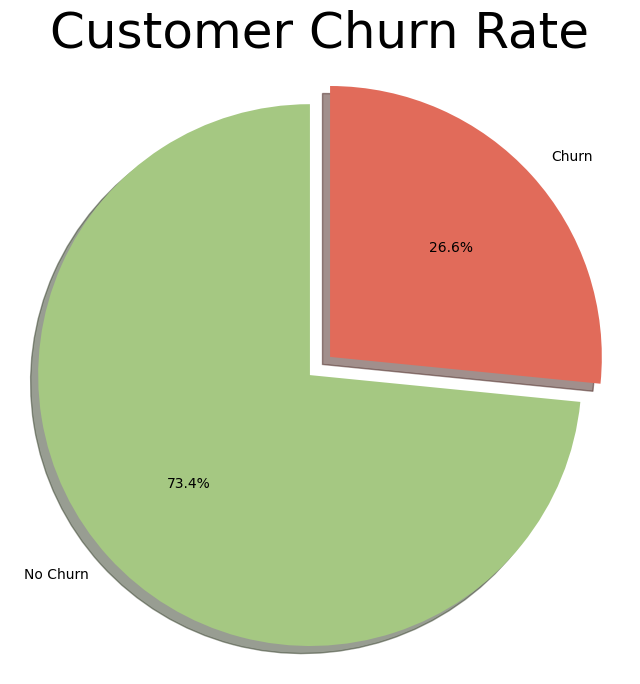

In [3]:
import matplotlib.pyplot as plt

# Calculate churn count
churn_counts = df['Churn'].value_counts()

# Calculate churn rate (percentage)
total_customers = churn_counts.sum()
churn_rate = churn_counts[1] / total_customers * 100
no_churn_rate = churn_counts[0] / total_customers * 100

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"No Churn Rate: {no_churn_rate:.2f}%")

# Create a pie chart
labels = ['No Churn', 'Churn']
sizes = [no_churn_rate, churn_rate]
colors = ['#a5c882','#e16b5a'] # Updated colors for better contrast
explode = (0, 0.1)  # Emphasize the churn slice

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Customer Churn Rate', fontsize=36)
plt.show()

In [4]:
# Check for missing values
print("Eksik değer kontrolü:\n", df.isnull().sum())

Eksik değer kontrolü:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-run train_test_split to ensure X_train and X_test are DataFrames
# This assumes X and y are already defined from previous cells.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Drop the 'customerID' column as it's an identifier and not useful for scaling or modeling
if 'customerID' in X_train.columns:
    X_train = X_train.drop('customerID', axis=1)
if 'customerID' in X_test.columns:
    X_test = X_test.drop('customerID', axis=1)

# Identify numerical and categorical columns after dropping 'customerID'
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
# StandardScaler for numerical features
numerical_transformer = StandardScaler()

# OneHotEncoder for categorical features
# handle_unknown='ignore' ensures the transformer can handle categories not seen during fit
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer
# This will apply different transformers to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep any other columns that are not explicitly transformed (shouldn't be any here)
)

# Apply the preprocessor to X_train and X_test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# The output of ColumnTransformer can be a sparse matrix, convert to dense array if needed
# Many models prefer dense arrays.
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# Convert target variable 'Churn' to numerical (0 for No, 1 for Yes)
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and binary classification

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

### Confusion Matrix Explanation

The confusion matrix provides a detailed breakdown of the model's predictions versus the actual outcomes:

*   **True Negatives (Top-Left):** The number of customers who did not churn and were correctly predicted as not churning. (916)
*   **False Positives (Top-Right):** The number of customers who did not churn but were incorrectly predicted as churning (Type I error). (117)
*   **False Negatives (Bottom-Left):** The number of customers who churned but were incorrectly predicted as not churning (Type II error). (180)
*   **True Positives (Bottom-Right):** The number of customers who churned and were correctly predicted as churning. (194)

This visualization helps us understand where the model is performing well and where it might be struggling. For instance, the model is quite good at identifying non-churning customers (high True Negatives) but has more difficulty correctly identifying churning customers (lower True Positives and higher False Negatives).

### Exploring Other Models: RandomForestClassifier

To increase the diversity in our modeling approach and potentially improve performance, let's try a RandomForestClassifier. This is an ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction. We'll train it on the same preprocessed data and evaluate its performance.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure y_test is numerical (0 and 1) to match y_pred
# This line ensures that y_test is converted to numeric if it's still categorical strings
if y_test.dtype == 'object':
    y_test_numeric = y_test.map({'Yes': 1, 'No': 0})
else:
    y_test_numeric = y_test

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_matrix(y_test_numeric, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier model
# Using n_estimators (number of trees) and random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the RandomForest model
print("RandomForestClassifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandomForestClassifier Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nRandomForestClassifier Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

### Comparing Model Performances

Let's visualize the Confusion Matrix for the RandomForestClassifier to compare it with our Logistic Regression model.

In [ ]:
# Visualize the Confusion Matrix for RandomForest
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('RandomForestClassifier Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### RandomForest Modelinin Özellik Önem Düzeyleri (Feature Importances)

RandomForest modelinin tahmin yaparken hangi özelliklere daha fazla odaklandığını görselleştirelim. Bu, modelin karar verme sürecindeki en önemli faktörleri anlamamızı sağlayacaktır.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained RandomForest model
feature_importances = rf_model.feature_importances_

# Get feature names after preprocessing
# This includes numerical features and one-hot encoded categorical features
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('RandomForestClassifier - Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

By comparing the metrics and confusion matrices of both models, we can see which one performs better for this specific task and dataset. This process of trying different models is key to finding the best solution for your AI problem.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# StratifiedKFold yapılandırması
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Logistic Regression için Çapraz Doğrulama ---")
# Logistic Regression için çapraz doğrulama skorlarını hesaplayın
# 'accuracy' değerlendirme metriği olarak kullanıldı
lr_cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"Logistic Regression Çapraz Doğrulama Skorları: {lr_cv_scores}")
print(f"Ortalama Logistic Regression Doğruluğu: {lr_cv_scores.mean():.4f}")
print(f"Logistic Regression Doğruluk Standart Sapması: {lr_cv_scores.std():.4f}")

print("\n--- RandomForest Classifier için Çapraz Doğrulama ---")
# RandomForest Classifier için çapraz doğrulama skorlarını hesaplayın
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"RandomForest Classifier Çapraz Doğrulama Skorları: {rf_cv_scores}")
print(f"Ortalama RandomForest Classifier Doğruluğu: {rf_cv_scores.mean():.4f}")
print(f"RandomForest Classifier Doğruluk Standart Sapması: {rf_cv_scores.std():.4f}")


### RandomForestClassifier için Hiperparametre Ayarlaması (Hyperparameter Tuning)

Hiperparametre ayarlaması, bir makine öğrenimi modelinin performansını optimize etmek için en iyi hiperparametre kombinasyonlarını bulma sürecidir. `RandomForestClassifier` gibi modellerde `n_estimators`, `max_depth`, `min_samples_split` ve `min_samples_leaf` gibi hiperparametreler modelin performansını önemli ölçüde etkileyebilir. `GridSearchCV` kullanarak en iyi parametreleri bulalım.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameters to be defined
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV setup
# estimator: model to be optimized
# param_grid: dictionary of hyperparameters to try
# cv: cross-validation strategy (using the previously defined StratifiedKFold)
# scoring: performance metric
# n_jobs: number of jobs to run in parallel (using 4 for stability)
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=skf, scoring='accuracy', n_jobs=4, verbose=2)

# Train GridSearchCV
grid_search_rf.fit(X_train, y_train)

# Print best parameters and best score
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_rf.best_score_:.4f}")

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions with the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the performance of the best model
print("\n--- Best RandomForestClassifier Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))

In [ ]:
import pandas as pd
import zipfile
import os
import pickle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# --- 1. Data Loading and Extraction ---
zip_file_path = "/content/archive.zip"
csv_file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
extracted_csv_path = os.path.join("/content/", csv_file_name)

# Check if the CSV file already exists, if not, try to extract it
if not os.path.exists(extracted_csv_path):
    if os.path.exists(zip_file_path):
        print(f"'{csv_file_name}' not found. Attempting to extract from '{zip_file_path}'.")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall("/content/") # Extract all contents to /content/
        print(f"'{zip_file_path}' extracted to '/content/'.")
    else:
        print(f"Error: '{zip_file_path}' not found. Cannot extract CSV. Please ensure archive.zip is uploaded.")
        # You might want to exit or raise an error here if the data is essential
else:
    print(f"'{csv_file_name}' already exists in '/content/'. Skipping extraction.")

# Attempt to read the CSV file
try:
    df = pd.read_csv(extracted_csv_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: CSV file not found even after extraction attempt.")
    exit() # Exit if data loading fails

# --- 2. Data Cleaning ---
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna() # Drop rows with NaN values after conversion
df["Churn"] = df["Churn"].map({"Yes":1, "No":0}) # Convert 'Churn' to numerical

print("Data cleaned: TotalCharges converted, NaNs dropped, Churn mapped to 0/1.")

# --- 3. Model Definition and Training ---
X = df.drop("Churn", axis=1) # Features
y = df["Churn"] # Target

# Identify numerical and categorical columns
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# Create a ColumnTransformer for preprocessing
preprocessor_step = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Create a Pipeline with preprocessing and RandomForestClassifier
model_pipeline = Pipeline([
    ("preprocess", preprocessor_step),
    ("clf", RandomForestClassifier(random_state=42)) # Added random_state for reproducibility
])

# Train the model pipeline
model_pipeline.fit(X, y)

print("Model pipeline defined and trained successfully!")

# --- 4. Model Saving (Entire Pipeline) ---
# Save the entire pipeline as model.pkl
with open('model.pkl', 'wb') as f:
    pickle.dump(model_pipeline, f)

# preprocessor.pkl is no longer needed as the preprocessor is part of the pipeline
# If you still want to save it separately for other uses, you can uncomment this part:
# with open('preprocessor.pkl', 'wb') as f:
#    pickle.dump(model_pipeline.named_steps['preprocess'], f)

print("✅ Entire Pipeline (model.pkl) saved successfully in the current directory!")

### ROC Eğrisi ve AUC Skoru

ROC (Receiver Operating Characteristic) eğrisi ve AUC (Area Under the Curve) skoru, özellikle sınıflandırma modellerinin performansını değerlendirmek için kullanılan önemli metriklerdir. Özellikle dengesiz veri kümelerinde modelin performansını daha iyi anlamamızı sağlarlar. AUC, modelin rastgele bir pozitif örneği, rastgele bir negatif örnekten daha yüksek bir olasılıkla sıralama yeteneğini temsil eder.

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# y_test'in sayısal (0, 1) olduğundan emin olalım
y_test_numeric = y_test.map({'Yes': 1, 'No': 0}) if y_test.dtype == 'object' else y_test

# Logistic Regression için ROC eğrisi ve AUC skoru
y_pred_proba_lr = model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_numeric, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# RandomForestClassifier için ROC eğrisi ve AUC skoru
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_numeric, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# En iyi RandomForestClassifier için ROC eğrisi ve AUC skoru
if 'best_rf_model' in globals():
    y_pred_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]
    fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test_numeric, y_pred_proba_best_rf)
    roc_auc_best_rf = auc(fpr_best_rf, tpr_best_rf)

# ROC Eğrilerini Çizdirme
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'RandomForest (AUC = {roc_auc_rf:.2f})')
if 'best_rf_model' in globals():
    plt.plot(fpr_best_rf, tpr_best_rf, color='orange', lw=2, label=f'Best RandomForest (AUC = {roc_auc_best_rf:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('Receiver Operating Characteristic (ROC) Eğrisi')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Check: Predict if best_rf_model exists in the current session
if 'best_rf_model' in globals():
    y_pred_best_rf = best_rf_model.predict(X_test)

    # Calculate confusion matrix for the best RF model
    cm_best_rf = confusion_matrix(y_test_numeric, y_pred_best_rf)

    # Visualize the Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Predicted No Churn', 'Predicted Churn'],
                yticklabels=['Actual No Churn', 'Actual Churn'])

    plt.title('Best RandomForest - Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("Error: 'best_rf_model' not found. Please complete the GridSearchCV cell (fea7bf7b) successfully first.")

In [ ]:
%whos

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Ensure y_test is converted to numeric for comparison with y_pred
y_test_numeric = y_test.map({'Yes': 1, 'No': 0}) if y_test.dtype == 'object' else y_test

# Logistic Regression Metrics
lr_accuracy = accuracy_score(y_test_numeric, y_pred)
lr_f1 = f1_score(y_test_numeric, y_pred, average='weighted')

print("--- Logistic Regression Performance ---")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1-Score (Weighted): {lr_f1:.4f}")

# Random Forest Metrics
# y_pred_rf is stored as strings ('Yes'/'No') in previous cells, convert to numeric
y_pred_rf_numeric = pd.Series(y_pred_rf).map({'Yes': 1, 'No': 0}) if y_pred_rf.dtype == 'object' else y_pred_rf
rf_accuracy = accuracy_score(y_test_numeric, y_pred_rf_numeric)
rf_f1 = f1_score(y_test_numeric, y_pred_rf_numeric, average='weighted')

print("\n--- Random Forest Performance ---")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1-Score (Weighted): {rf_f1:.4f}")

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X DataFrame shape:", X.shape)
print("y Series shape:", y.shape)
print("First 5 rows of y:")
print(y.head())

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(preprocessor, open("preprocessor.pkl", "wb")) # Changed from scaler to preprocessor
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("columns.pkl")

In [ ]:
from sklearn.linear_model import LogisticRegression
import pickle

# Re-train using the 45-feature training set created by the ColumnTransformer
final_model = LogisticRegression(random_state=42, solver='liblinear')
final_model.fit(X_train, y_train)

# Save with consistent naming for the Streamlit app
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Model and Preprocessor successfully synchronized (45 features).")

In [ ]:
import pickle
import pandas as pd
import numpy as np

# Final validation test
try:
    loaded_model = pickle.load(open('model.pkl', 'rb'))
    loaded_preprocessor = pickle.load(open('preprocessor.pkl', 'rb'))

    # Test with X_test (which has 45 features)
    test_sample = X_test[0].reshape(1, -1)
    prediction = loaded_model.predict(test_sample)

    print("✅ Success! Feature dimensions are now compatible.")
    print(f"✅ Sample Prediction: {prediction[0]}")
except Exception as e:
    print(f"❌ Error: {e}")

### Streamlit Uygulama Kodu Örneği

Bu kod bloğunu bir `app.py` dosyası olarak kaydedin:

In [ ]:
app_code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# 1. Load saved assets
def load_assets():
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('preprocessor.pkl', 'rb') as f:
        preprocessor = pickle.load(f)
    return model, preprocessor

try:
    model, preprocessor = load_assets()
    st.success("Model and Preprocessor loaded successfully!")
except Exception as e:
    st.error(f"Error loading files: {e}")
    st.stop()

st.title("📱 Telco Customer Churn Prediction")
st.markdown("Enter customer details to calculate the probability of churn.")

# 2. User Interface (Inputs)
col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1])
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0)
charges_t = st.number_input("Total Charges", value=tenure * charges_m)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    # Preprocessing
    input_processed = preprocessor.transform(input_df)

    # Prediction
    prediction = model.predict(input_processed)
    probability = model.predict_proba(input_processed)[0][1]

    st.divider()
    if prediction[0] == 1 or prediction[0] == 'Yes':
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%)")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%)")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py has been updated with English text. Place model.pkl, preprocessor.pkl, and app.py in the same folder.")

In [ ]:
app_code_final = """
import streamlit as st
import pandas as pd
import pickle

st.title("Churn App (Minimal Test)")

# Load the model pipeline (preprocessor is now part of the pipeline)
def load_model_pipeline():
    with open("model.pkl", "rb") as f:
        model_pipeline = pickle.load(f)
    return model_pipeline

try:
    model_pipeline = load_model_pipeline()
    st.success("Model Pipeline loaded successfully!")
except Exception as e:
    st.error(f"Error loading model file: {e}")
    st.stop()

# Enter dataset columns exactly (including case!)
tenure = st.number_input("tenure", 0, 72, 12)
MonthlyCharges = st.number_input("MonthlyCharges", 0.0, 200.0, 50.0)
TotalCharges = st.number_input("TotalCharges", 0.0, 10000.0, 500.0)
Contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
PaymentMethod = st.selectbox("PaymentMethod", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
InternetService = st.selectbox("InternetService", ["DSL", "Fiber optic", "No"])

# You must add all inputs expected by the model here.
# These are the columns from the X dataframe obtained from df.drop("Churn", axis=1).
# If your model's trained X dataframe has more columns (e.g., gender, SeniorCitizen, etc.),
# you should add them to the Streamlit interface or assign default values.
input_dict = {
    "tenure": tenure,
    "MonthlyCharges": MonthlyCharges,
    "TotalCharges": TotalCharges,
    "Contract": Contract,
    "PaymentMethod": PaymentMethod,
    "InternetService": InternetService,
    'gender': 'Male', # Example value, you may need to add this for all columns expected by the model.
    'SeniorCitizen': 0, # Example value
    'Partner': 'No', # Example value
    'Dependents': 'No', # Example value
    'PhoneService': 'No', # Example value
    'MultipleLines': 'No phone service', # Example value
    'OnlineSecurity': 'No internet service', # Example value
    'OnlineBackup': 'No internet service', # Example value
    'DeviceProtection': 'No internet service', # Example value
    'TechSupport': 'No internet service', # Example value
    'StreamingTV': 'No internet service', # Example value
    'StreamingMovies': 'No internet service', # Example value
    'PaperlessBilling': 'No' # Example value
}

input_df = pd.DataFrame([input_dict])

if st.button("Predict"):
    st.write("Input:", input_df)
    # Make predictions using the pipeline. Preprocessing is automatically applied.
    pred = model_pipeline.predict(input_df)
    probability = model_pipeline.predict_proba(input_df)[0]

    st.write("Prediction:", pred)
    st.write("Probability (No Churn, Churn):", probability)
    if pred[0] == 1:
        st.error(f"🚨 Customer is likely to churn! (Probability: {probability[1]*100:.2f}%) ")
    else:
        st.success(f"✅ Customer is likely to stay. (Probability: {probability[0]*100:.2f}%) ")
"""

with open('app.py', 'w') as f:
    f.write(app_code_final)

print("✅ 'app.py' file has been updated. You should now only download the 'model.pkl' file and use it with your Streamlit application.")

In [ ]:
from google.colab import files
import os

# Dosyaların varlığını kontrol et
required_files = ['model.pkl', 'preprocessor.pkl', 'app.py']
for f in required_files:
    if os.path.exists(f):
        print(f"✅ {f} hazır, indiriliyor...")
        files.download(f)
    else:
        print(f"❌ {f} bulunamadı! Lütfen ilgili hücreleri tekrar çalıştırın.")

In [ ]:
from google.colab import files
import os

# List of files to download
files_to_download = ['model.pkl', 'scaler.pkl', 'columns.pkl']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"Downloading {file_name}...")
        files.download(file_name)
    else:
        print(f"Error: {file_name} not found in the current directory.")

In [ ]:
import pickle
import os
from google.colab import files

# Preprocessor (scaler) nesnesini Streamlit'in beklediği isimle kaydedelim
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print('✅ preprocessor.pkl başarıyla oluşturuldu.')

# Şimdi dosyayı indirelim
if os.path.exists('preprocessor.pkl'):
    files.download('preprocessor.pkl')
else:
    print('❌ Dosya oluşturulamadı.')

In [ ]:
import pandas as pd
import pickle

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Ensure 'extracted_csv_path' is defined by running the initial data loading cell (e.g., 6p_9R2fY0AuB) first.

# DATA Loading and Cleaning
df = pd.read_csv(extracted_csv_path) # Use the correctly extracted path

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

X = df.drop("Churn", axis=1)
y = df["Churn"]

# COLUMN TYPES
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# PIPELINE
# Define the preprocessor step within the pipeline
preprocessor_step = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline([
    ("preprocess", preprocessor_step),
    ("clf", RandomForestClassifier(random_state=42)) # Added random_state for reproducibility
])

# TRAIN the model pipeline
model.fit(X, y)

# Extract the preprocessor from the trained pipeline for separate saving if needed
# The preprocessor is the first step in the pipeline, named 'preprocess'.
preprocessor = model.named_steps['preprocess']

print("Model and Preprocessor defined and trained successfully!")

In [ ]:
import pickle
import os

# Assuming 'preprocessor' variable is available from the last run of the pipeline definition cell (NDsyzDZ4QT9k)
# Save the preprocessor separately to check its size
preprocessor_temp_path = 'preprocessor_temp.pkl'
with open(preprocessor_temp_path, 'wb') as f:
    pickle.dump(preprocessor, f)

preprocessor_size_mb = os.path.getsize(preprocessor_temp_path) / (1024 * 1024)
print(f"Size of preprocessor_temp.pkl: {preprocessor_size_mb:.2f} MB")

# You can remove this temporary file if you don't need it
os.remove(preprocessor_temp_path)

If the `preprocessor_temp.pkl` is large, it's likely due to the `OneHotEncoder` capturing a lot of unique categories from your data. Here are a few strategies to manage large model files:

1.  **Review Categorical Features:** Check if all categorical features are necessary. Sometimes, features with too many unique values (high cardinality) can lead to a very large `OneHotEncoder` output. Consider techniques like target encoding, feature hashing, or grouping rare categories.
2.  **Feature Selection:** Reduce the number of features before training your model. Fewer features mean a smaller preprocessor and potentially a smaller model.
3.  **Git Large File Storage (LFS):** If the model size is inherently large and cannot be reduced significantly without impacting performance, Git LFS is designed for tracking large files in Git repositories. You would install Git LFS, track `.pkl` files, and then push them to your repository.

In [ ]:
import pickle

# Assuming 'model' is the trained pipeline and 'preprocessor' is the ColumnTransformer extracted from it.
# These should be defined by successfully running cell NDsyzDZ4QT9k.

# Save only the classifier from the pipeline as model.pkl
with open('model.pkl', 'wb') as f:
    pickle.dump(model.named_steps['clf'], f)

# Save the preprocessor as preprocessor.pkl
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Classifier (model.pkl) and Preprocessor (preprocessor.pkl) saved successfully!")

In [ ]:
import pickle
import os

# Assuming 'model' from cell 43e8d8e9 is the Logistic Regression model
# and 'preprocessor' from cell xkyfQWoY5uCZ is the ColumnTransformer.

# Save the Logistic Regression model as model.pkl
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the preprocessor as preprocessor.pkl
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Logistic Regression model (model.pkl) and Preprocessor (preprocessor.pkl) saved successfully!")

# Check and print the sizes of the new files
model_size_mb = os.path.getsize('model.pkl') / (1024 * 1024)
preprocessor_size_mb = os.path.getsize('preprocessor.pkl') / (1024 * 1024)

print(f"New model.pkl size: {model_size_mb:.4f} MB")
print(f"New preprocessor.pkl size: {preprocessor_size_mb:.4f} MB")

Now that we've saved the Logistic Regression model and preprocessor separately, we need to adjust the `app.py` code to load them individually for prediction. This is similar to an earlier version of the `app.py` you had.

In [ ]:
app_code_for_separate_model_preprocessor = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

st.set_page_config(layout="wide")
st.title("📱 Telco Customer Churn Prediction (Logistic Regression)")
st.markdown("Enter customer details to predict churn likelihood using a Logistic Regression model.")

# 1. Load saved assets (model and preprocessor separately)
def load_assets():
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('preprocessor.pkl', 'rb') as f:
        preprocessor = pickle.load(f)
    return model, preprocessor

try:
    model, preprocessor = load_assets()
    st.success("Logistic Regression Model and Preprocessor loaded successfully!")
except Exception as e:
    st.error(f"Error loading model or preprocessor files: {e}")
    st.stop()

# 2. User Interface (Inputs)
# Note: Ensure all features expected by the preprocessor are included here
# customerID should *not* be part of these inputs if it was dropped during preprocessing

col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0, min_value=0.0)
charges_t = st.number_input("Total Charges", value=float(tenure * charges_m), min_value=0.0)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    # Preprocessing with the separate preprocessor
    input_processed = preprocessor.transform(input_df)

    # Prediction with the separate model
    prediction = model.predict(input_processed)
    probability = model.predict_proba(input_processed)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_for_separate_model_preprocessor)

print("✅ 'app.py' has been updated to use separate model.pkl (Logistic Regression) and preprocessor.pkl.")

In [ ]:
from sklearn.linear_model import LogisticRegression
import pickle
import os

# Ensure X_train, y_train, and preprocessor are available
# If you restarted the notebook, you might need to re-run cells:
# 6p_9R2fY0AuB (data load)
# FkPyPM8B5cbb (data clean)
# xkyfQWoY5uCZ (preprocessing, X_train, X_test)
# 6e6e815b (y_train, y_test mapping)

# Re-initialize and re-train the Logistic Regression model
final_logistic_model = LogisticRegression(random_state=42, solver='liblinear')
final_logistic_model.fit(X_train, y_train)

# Save the Logistic Regression model as model.pkl
with open('model.pkl', 'wb') as f:
    pickle.dump(final_logistic_model, f)

# Save the preprocessor as preprocessor.pkl
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Logistic Regression model (model.pkl) and Preprocessor (preprocessor.pkl) saved successfully!")

# Check and print the sizes of the new files
model_size_mb = os.path.getsize('model.pkl') / (1024 * 1024)
preprocessor_size_mb = os.path.getsize('preprocessor.pkl') / (1024 * 1024)

print(f"New model.pkl size: {model_size_mb:.4f} MB")
print(f"New preprocessor.pkl size: {preprocessor_size_mb:.4f} MB")

In [14]:
import pandas as pd
import zipfile
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import numpy as np # For numpy.number in select_dtypes
from sklearn.pipeline import Pipeline # Import Pipeline

# --- 1. Veri Yükleme ve Çıkartma ---
zip_file_path = "/content/archive.zip"
csv_file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
extracted_csv_path = os.path.join("/content/", csv_file_name)

if not os.path.exists(extracted_csv_path):
    if os.path.exists(zip_file_path):
        print(f"'{csv_file_name}' bulunamadı. '{zip_file_path}' dosyasından çıkartılıyor.")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall("/content/")
        print(f"'{zip_file_path}' '/content/' dizinine çıkartıldı.")
    else:
        print(f"Hata: '{zip_file_path}' bulunamadı. CSV çıkartılamıyor. Lütfen 'archive.zip' dosyasını yüklediğinizden emin olun.")
        # Veri önemliyse buradan çıkış yapılabilir veya hata fırlatılabilir.
else:
    print(f"'{csv_file_name}' zaten '/content/' dizininde mevcut. Çıkartma atlanıyor.")

try:
    df = pd.read_csv(extracted_csv_path)
    print("Veri başarıyla yüklendi.")
except FileNotFoundError:
    print("Hata: Çıkartma denemesinden sonra bile CSV dosyası bulunamadı.")
    # raise FileNotFoundError("CSV dosyası bulunamadı.")

# --- 2. Veri Temizleme ---
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna() # Dönüştürme sonrası NaN değer içeren satırları düşür

print("Veri temizlendi: TotalCharges dönüştürüldü, NaN değerler düşürüldü.")

# --- 3. X ve y Tanımlama ---
X = df.drop("Churn", axis=1) # Özellikler
y = df["Churn"] # Hedef değişken

# --- 4. Eğitim ve Test Setlerine Ayırma ---
# Split before dropping customerID for consistency if X was used for preprocessing directly before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Veri eğitim ve test setlerine ayrıldı.")

# --- 5. customerID Sütununu Drop Etme ---
# Pipeline'ın bu sütunu görmemesi için burada drop ediyoruz.
# Alternatif olarak ColumnTransformer'ın `drop` or `passthrough` ile de yönetilebilir.
if 'customerID' in X_train.columns:
    X_train = X_train.drop('customerID', axis=1)
if 'customerID' in X_test.columns:
    X_test = X_test.drop('customerID', axis=1)
print("'customerID' sütunu eğitim ve test setlerinden çıkarıldı.")


# --- 6. Önişleme Adımlarını Tanımlama ---
# 'customerID' düşürüldükten sonra sayısal ve kategorik sütunları belirle
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor_step = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)
print("Önişleme adımları tanımlandı.")

# --- 7. y_train ve y_test'i Haritala (Sayısal dönüştür) ---
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})
print("Hedef değişkenler sayısal formata dönüştürüldü.")

# --- 8. Model Pipeline Oluşturma ve Eğitme ---
# Şimdi tüm önişleme adımlarını ve modeli bir pipeline'da birleştiriyoruz.
final_pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor_step),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Pipeline'ı Orijinal (henüz transform edilmemiş) X_train üzerinde eğitin
final_pipeline_model.fit(X_train, y_train)
print("Model pipeline oluşturuldu ve eğitildi.")

# --- 9. Modeli Kaydet ---
with open('model.pkl', 'wb') as f:
    pickle.dump(final_pipeline_model, f)

# preprocessor.pkl artık ayrı olarak kaydedilmesine gerek yok çünkü pipeline içinde.
print("✅ Model pipeline (model.pkl) başarıyla kaydedildi!")

# --- 10. Boyutları Kontrol Et ve Yazdır ---
model_size_mb = os.path.getsize('model.pkl') / (1024 * 1024)

print(f"Yeni model.pkl boyutu: {model_size_mb:.4f} MB")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [10]:
from google.colab import files
import os

# app.py dosyasını da yeniden oluşturalım ve indirilmek üzere hazırlayalım
app_code_english_updated = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np
import sklearn # Add this import to check version

st.set_page_config(layout="wide")
st.title("📱 Telco Customer Churn Prediction (Logistic Regression)")
st.markdown("Enter customer details to predict churn likelihood using a Logistic Regression model.")

# Add this line to print the scikit-learn version
st.text(f"Streamlit App Scikit-learn Version: {sklearn.__version__}")

# 1. Load the unified model pipeline
def load_model_pipeline():
    with open('model.pkl', 'rb') as f:
        model_pipeline = pickle.load(f)
    return model_pipeline

try:
    model_pipeline = load_model_pipeline()
    st.success("Logistic Regression Model Pipeline loaded successfully!")
except Exception as e:
    st.error(f"Error loading model pipeline file: {e}")
    st.stop()

# 2. User Interface (Inputs)
col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0, min_value=0.0)
charges_t = st.number_input("Total Charges", value=float(tenure * charges_m), min_value=0.0)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    prediction = model_pipeline.predict(input_df)
    probability = model_pipeline.predict_proba(input_df)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_english_updated)

print("✅ 'app.py' dosyası güncellendi.")

# İndirilecek dosyalar
files_to_download = ['model.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' indiriliyor...")
        files.download(file_name)
    else:
        print(f"Hata: '{file_name}' bulunamadı. Lütfen tüm adımları doğru şekilde çalıştırdığınızdan emin olun.")

✅ 'app.py' dosyası güncellendi.
'model.pkl' indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'app.py' indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os

file_name = 'model.pkl'
if os.path.exists(file_name):
    print(f"'{file_name}' indiriliyor...")
    files.download(file_name)
else:
    print(f"Hata: '{file_name}' bulunamadı. Lütfen modelin oluşturulduğundan emin olun.")

In [ ]:
app_code_turkish = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

st.set_page_config(layout="wide")
st.title("📱 Telco Müşteri Kaybı Tahmini (Lojistik Regresyon)")
st.markdown("Müşteri kaybı olasılığını tahmin etmek için müşteri bilgilerini girin.")

# 1. Kaydedilmiş varlıkları yükle (model ve önişleyici ayrı ayrı)
def load_assets():
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('preprocessor.pkl', 'rb') as f:
        preprocessor = pickle.load(f)
    return model, preprocessor

try:
    model, preprocessor = load_assets()
    st.success("Lojistik Regresyon Modeli ve Önişleyici başarıyla yüklendi!")
except Exception as e:
    st.error(f"Model veya önişleyici dosyaları yüklenirken hata oluştu: {e}")
    st.stop()

# 2. Kullanıcı Arayüzü (Girişler)
# Not: Önişleyici tarafından beklenen tüm özelliklerin buraya dahil edildiğinden emin olun.
# 'customerID', önişleme sırasında çıkarıldıysa bu girişlere dahil edilmemelidir.

col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Cinsiyet", ["Kadın", "Erkek"])
    senior = st.selectbox("Kıdemli Vatandaş mı?", [0, 1], format_func=lambda x: 'Evet' if x == 1 else 'Hayır')
    partner = st.selectbox("Partneri Var mı?", ["Evet", "Hayır"])
    dependents = st.selectbox("Bağımlıları Var mı?", ["Evet", "Hayır"])
    tenure = st.slider("Müşteri Kalma Süresi (Ay)", 0, 72, 12)
    phone = st.selectbox("Telefon Hizmeti", ["Evet", "Hayır"])
    multiple = st.selectbox("Birden Çok Hat", ["Hayır", "Evet", "Telefon hizmeti yok"])

with col2:
    internet = st.selectbox("İnternet Hizmeti", ["DSL", "Fiber optik", "Yok"])
    security = st.selectbox("Çevrimiçi Güvenlik", ["Hayır", "Evet", "İnternet hizmeti yok"])
    backup = st.selectbox("Çevrimiçi Yedekleme", ["Hayır", "Evet", "İnternet hizmeti yok"])
    protection = st.selectbox("Cihaz Koruması", ["Hayır", "Evet", "İnternet hizmeti yok"])
    support = st.selectbox("Teknik Destek", ["Hayır", "Evet", "İnternet hizmeti yok"])
    tv = st.selectbox("TV Yayını", ["Hayır", "Evet", "İnternet hizmeti yok"])
    movies = st.selectbox("Film Yayını", ["Hayır", "Evet", "İnternet hizmeti yok"])

contract = st.selectbox("Sözleşme Türü", ["Aydan aya", "Bir yıllık", "İki yıllık"])
billing = st.selectbox("Kağıtsız Fatura", ["Evet", "Hayır"])
payment = st.selectbox("Ödeme Yöntemi", ["Elektronik çek", "Posta çeki", "Otomatik banka havalesi", "Otomatik kredi kartı"])
charges_m = st.number_input("Aylık Ücretler", value=50.0, min_value=0.0)
charges_t = st.number_input("Toplam Ücretler", value=float(tenure * charges_m), min_value=0.0)

# 3. Tahmin Mantığı
if st.button("Kaybı Tahmin Et"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    # Ayrı önişleyici ile önişleme
    input_processed = preprocessor.transform(input_df)

    # Ayrı model ile tahmin
    prediction = model.predict(input_processed)
    probability = model.predict_proba(input_processed)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Müşteri kayıp etme olasılığı yüksek! (Olasılık: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Müşteri kalma olasılığı yüksek. (Olasılık: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_turkish)

print("✅ 'app.py' dosyası Türkçe metinlerle güncellendi. Artık 'model.pkl' ve 'preprocessor.pkl' dosyalarını indirip Streamlit uygulamanızla birlikte kullanmalısınız.")

In [ ]:
from google.colab import files
import os

# İndirilecek dosyalar
files_to_download = ['model.pkl', 'preprocessor.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' indiriliyor...")
        files.download(file_name)
    else:
        print(f"Hata: '{file_name}' bulunamadı. Lütfen tüm adımları doğru şekilde çalıştırdığınızdan emin olun.")

In [ ]:
app_code_english = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

st.set_page_config(layout="wide")
st.title("📱 Telco Customer Churn Prediction (Logistic Regression)")
st.markdown("Enter customer details to predict churn likelihood using a Logistic Regression model.")

# 1. Load the unified model pipeline
def load_model_pipeline():
    with open('model.pkl', 'rb') as f:
        model_pipeline = pickle.load(f)
    return model_pipeline

try:
    model_pipeline = load_model_pipeline()
    st.success("Logistic Regression Model Pipeline loaded successfully!")
except Exception as e:
    st.error(f"Error loading model pipeline file: {e}")
    st.stop()

# 2. User Interface (Inputs)
# Note: Ensure all features expected by the pipeline are included here.
# 'customerID' should *not* be part of these inputs if it was dropped during preprocessing.

col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0, min_value=0.0)
charges_t = st.number_input("Total Charges", value=float(tenure * charges_m), min_value=0.0)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    # Make predictions using the pipeline. Preprocessing is automatically applied.
    prediction = model_pipeline.predict(input_df)
    probability = model_pipeline.predict_proba(input_df)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_english)

print("✅ 'app.py' has been updated with English text, configured to load the unified model pipeline.")

In [ ]:
from google.colab import files
import os

# Files to download (only the pipeline model and the updated app.py)
files_to_download = ['model.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' downloading...")
        files.download(file_name)
    else:
        print(f"Error: '{file_name}' not found. Please ensure all steps have been executed correctly.")

In [ ]:
app_code_english = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

st.set_page_config(layout="wide")
st.title("📱 Telco Customer Churn Prediction (Logistic Regression)")
st.markdown("Enter customer details to predict churn likelihood using a Logistic Regression model.")

# 1. Load the unified model pipeline
def load_model_pipeline():
    with open('model.pkl', 'rb') as f:
        model_pipeline = pickle.load(f)
    return model_pipeline

try:
    model_pipeline = load_model_pipeline()
    st.success("Logistic Regression Model Pipeline loaded successfully!")
except Exception as e:
    st.error(f"Error loading model pipeline file: {e}")
    st.stop()

# 2. User Interface (Inputs)
# Note: Ensure all features expected by the pipeline are included here.
# 'customerID' should *not* be part of these inputs if it was dropped during preprocessing.

col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0, min_value=0.0)
charges_t = st.number_input("Total Charges", value=float(tenure * charges_m), min_value=0.0)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    # Make predictions using the pipeline. Preprocessing is automatically applied.
    prediction = model_pipeline.predict(input_df)
    probability = model_pipeline.predict_proba(input_df)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_english)

print("✅ 'app.py' has been updated with English text, configured to load the unified model pipeline.")

In [ ]:
from google.colab import files
import os

# Files to download (only the pipeline model and the updated app.py)
files_to_download = ['model.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' downloading...")
        files.download(file_name)
    else:
        print(f"Error: '{file_name}' not found. Please ensure all steps have been executed correctly.")

In [ ]:
app_code_english = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

st.set_page_config(layout="wide")
st.title("📱 Telco Customer Churn Prediction (Logistic Regression)")
st.markdown("Enter customer details to predict churn likelihood using a Logistic Regression model.")

# 1. Load the unified model pipeline
def load_model_pipeline():
    with open('model.pkl', 'rb') as f:
        model_pipeline = pickle.load(f)
    return model_pipeline

try:
    model_pipeline = load_model_pipeline()
    st.success("Logistic Regression Model Pipeline loaded successfully!")
except Exception as e:
    st.error(f"Error loading model pipeline file: {e}")
    st.stop()

# 2. User Interface (Inputs)
# Note: Ensure all features expected by the pipeline are included here.
# 'customerID' should *not* be part of these inputs if it was dropped during preprocessing.

col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0, min_value=0.0)
charges_t = st.number_input("Total Charges", value=float(tenure * charges_m), min_value=0.0)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    # Make predictions using the pipeline. Preprocessing is automatically applied.
    prediction = model_pipeline.predict(input_df)
    probability = model_pipeline.predict_proba(input_df)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_english)

print("✅ 'app.py' has been updated with English text, configured to load the unified model pipeline.")

In [ ]:
import sklearn
print(f"Colab'daki scikit-learn versiyonu: {sklearn.__version__}")

In [ ]:
import pandas as pd
import zipfile
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.pipeline import Pipeline

# --- 1. Veri Yükleme ve Çıkartma ---
zip_file_path = "/content/archive.zip"
csv_file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
extracted_csv_path = os.path.join("/content/", csv_file_name)

if not os.path.exists(extracted_csv_path):
    if os.path.exists(zip_file_path):
        print(f"'{csv_file_name}' bulunamadı. '{zip_file_path}' dosyasından çıkartılıyor.")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall("/content/")
        print(f"'{zip_file_path}' '/content/' dizinine çıkartıldı.")
    else:
        print(f"Hata: '{zip_file_path}' bulunamadı. CSV çıkartılamıyor. Lütfen 'archive.zip' dosyasını yüklediğinizden emin olun.")
else:
    print(f"'{csv_file_name}' zaten '/content/' dizininde mevcut. Çıkartma atlanıyor.")

try:
    df = pd.read_csv(extracted_csv_path)
    print("Veri başarıyla yüklendi.")
except FileNotFoundError:
    print("Hata: Çıkartma denemesinden sonra bile CSV dosyası bulunamadı.")

# --- 2. Veri Temizleme ---
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

print("Veri temizlendi: TotalCharges dönüştürüldü, NaN değerler düşürüldü.")

# --- 3. X ve y Tanımlama ---
X = df.drop("Churn", axis=1)
y = df["Churn"]

# --- 4. Eğitim ve Test Setlerine Ayırma ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Veri eğitim ve test setlerine ayrıldı.")

# --- 5. customerID Sütununu Drop Etme ---
if 'customerID' in X_train.columns:
    X_train = X_train.drop('customerID', axis=1)
if 'customerID' in X_test.columns:
    X_test = X_test.drop('customerID', axis=1)
print("'customerID' sütunu eğitim ve test setlerinden çıkarıldı.")


# --- 6. Önişleme Adımlarını Tanımlama ---
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor_step = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)
print("Önişleme adımları tanımlandı.")

# --- 7. y_train ve y_test'i Haritala (Sayısal dönüştür) ---
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})
print("Hedef değişkenler sayısal formata dönüştürüldü.")

# --- 8. Model Pipeline Oluşturma ve Eğitme ---
final_pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor_step),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

final_pipeline_model.fit(X_train, y_train)
print("Model pipeline oluşturuldu ve eğitildi.")

# --- 9. Modeli Kaydet ---
with open('model.pkl', 'wb') as f:
    pickle.dump(final_pipeline_model, f)

print("✅ Model pipeline (model.pkl) başarıyla kaydedildi!")

# --- 10. Boyutları Kontrol Et ve Yazdır ---
model_size_mb = os.path.getsize('model.pkl') / (1024 * 1024)
print(f"Yeni model.pkl boyutu: {model_size_mb:.4f} MB")

In [9]:
print('Scikit-learn ve numpy versiyonlarını uyumlu olacak şekilde yüklüyorum.')
!pip install scikit-learn==1.2.2 numpy==1.23.5 --force-reinstall -q

import sklearn
import numpy
print(f"Yüklenmiş scikit-learn versiyonu: {sklearn.__version__}")
print(f"Yüklenmiş numpy versiyonu: {numpy.__version__}")
print("⚠️ Lütfen Colab çalışma zamanını (Runtime -> Restart runtime...) yeniden başlatın ve bu hücreyi atlayarak modelin yeniden eğitilmesi için ilgili hücreleri çalıştırın.")

Scikit-learn ve numpy versiyonlarını uyumlu olacak şekilde yüklüyorum.
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
from google.colab import files
import os

# app.py dosyasını da yeniden oluşturalım ve indirilmek üzere hazırlayalım
app_code_english_updated = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np
import sklearn # Add this import to check version

st.set_page_config(layout="wide")
st.title("📱 Telco Customer Churn Prediction (Logistic Regression)")
st.markdown("Enter customer details to predict churn likelihood using a Logistic Regression model.")

# Add this line to print the scikit-learn version
st.text(f"Streamlit App Scikit-learn Version: {sklearn.__version__}")

# 1. Load the unified model pipeline
def load_model_pipeline():
    with open('model.pkl', 'rb') as f:
        model_pipeline = pickle.load(f)
    return model_pipeline

try:
    model_pipeline = load_model_pipeline()
    st.success("Logistic Regression Model Pipeline loaded successfully!")
except Exception as e:
    st.error(f"Error loading model pipeline file: {e}")
    st.stop()

# 2. User Interface (Inputs)
col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"])
    senior = st.selectbox("Senior Citizen?", [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    partner = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])
    multiple = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])

with col2:
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["No", "Yes", "No internet service"])
    backup = st.selectbox("Online Backup", ["No", "Yes", "No internet service"])
    protection = st.selectbox("Device Protection", ["No", "Yes", "No internet service"])
    support = st.selectbox("Tech Support", ["No", "Yes", "No internet service"])
    tv = st.selectbox("Streaming TV", ["No", "Yes", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["No", "Yes", "No internet service"])

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])
charges_m = st.number_input("Monthly Charges", value=50.0, min_value=0.0)
charges_t = st.number_input("Total Charges", value=float(tenure * charges_m), min_value=0.0)

# 3. Prediction Logic
if st.button("Predict Churn"):
    input_dict = {
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner, 'Dependents': dependents,
        'tenure': tenure, 'PhoneService': phone, 'MultipleLines': multiple,
        'InternetService': internet, 'OnlineSecurity': security, 'OnlineBackup': backup,
        'DeviceProtection': protection, 'TechSupport': support, 'StreamingTV': tv,
        'StreamingMovies': movies, 'Contract': contract, 'PaperlessBilling': billing,
        'PaymentMethod': payment, 'MonthlyCharges': charges_m, 'TotalCharges': charges_t
    }

    input_df = pd.DataFrame([input_dict])

    prediction = model_pipeline.predict(input_df)
    probability = model_pipeline.predict_proba(input_df)[0][1]

    st.divider()
    if prediction[0] == 1:
        st.error(f"🚨 Customer is likely to Churn! (Probability: {probability*100:.2f}%) 🔥")
    else:
        st.success(f"✅ Customer is likely to Stay. (Probability: {probability*100:.2f}%) 🎉")
"""

with open('app.py', 'w') as f:
    f.write(app_code_english_updated)

print("✅ 'app.py' dosyası güncellendi.")

# İndirilecek dosyalar
files_to_download = ['model.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' indiriliyor...")
        files.download(file_name)
    else:
        print(f"Hata: '{file_name}' bulunamadı. Lütfen tüm adımları doğru şekilde çalıştırdığınızdan emin olun.")

In [ ]:
import sklearn
print(f"Scikit-learn version in Colab: {sklearn.__version__}")

In [ ]:
from google.colab import files
import os

# İndirilecek dosyalar (pipeline modeli ve güncellenmiş app.py)
files_to_download = ['model.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' indiriliyor...")
        files.download(file_name)
    else:
        print(f"Hata: '{file_name}' bulunamadı. Lütfen tüm adımları doğru şekilde çalıştırdığınızdan emin olun.")

### Streamlit Uygulamasını Colab İçinde Çalıştırma

Yerel kurulum sorunlarını aşmak için Streamlit uygulamasını doğrudan Colab ortamında çalıştırabiliriz. Bunun için gerekli kütüphaneleri kurup, uygulamanızı dışarıya açmak için `ngrok` kullanacağız.

In [ ]:
# Streamlit ve pyngrok kütüphanelerini Colab ortamına kurun
!pip install streamlit pyngrok -q
print("✅ Streamlit ve pyngrok yüklendi.")

### Streamlit Uygulamasını Başlat

Şimdi `app.py` dosyanızı bir `ngrok` tüneli üzerinden çalıştırabiliriz. Bu, size uygulamanıza erişebileceğiniz bir genel URL sağlayacaktır.

In [ ]:
from pyngrok import ngrok
import subprocess
import time
import threading

# Streamlit uygulamasını arka planda başlatmak için bir fonksiyon
def run_streamlit():
    # Streamlit uygulamasını 8501 portunda başlatır
    cmd = ["streamlit", "run", "app.py", "--server.port", "8501", "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"]
    p = subprocess.Popen(cmd)
    p.wait() # Streamlit süreci tamamlanana kadar bekler

# Streamlit'i ayrı bir iş parçacığında başlat
streamlit_thread = threading.Thread(target=run_streamlit)
streamlit_thread.start()

time.sleep(5) # Streamlit'in başlaması için biraz bekle

# ngrok tünelini oluştur
# Streamlit'in varsayılan portu 8501'dir.
public_url = ngrok.connect(8501)
print(f"Streamlit uygulaması burada çalışıyor: {public_url}")
print("Uygulamaya erişmek için yukarıdaki linke tıklayın.")
print("Tüneli kapatmak için: `ngrok.kill()` komutunu çalıştırın.")

In [ ]:
from google.colab import files
import os

# Indirilecek dosyalar
files_to_download = ['model.pkl', 'app.py']

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"'{file_name}' indiriliyor...")
        files.download(file_name)
    else:
        print(f"Hata: '{file_name}' bulunamadı. Lütfen tüm adımları doğru şekilde çalıştırdığınızdan emin olun.")

In [ ]:
import pickle

# Assuming 'model' is the trained pipeline and 'preprocessor' is the ColumnTransformer extracted from it.
# These should be defined by successfully running cell NDsyzDZ4QT9k.

# Save only the classifier from the pipeline as model.pkl
with open('model.pkl', 'wb') as f:
    pickle.dump(model.named_steps['clf'], f)

# Save the preprocessor as preprocessor.pkl
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Classifier (model.pkl) and Preprocessor (preprocessor.pkl) saved successfully!")

In [ ]:
from google.colab import files
import os

file_name = 'model.pkl'
if os.path.exists(file_name):
    print(f"'model.pkl' dosyasını indiriyorum...")
    files.download(file_name)
else:
    print(f"Hata: '{file_name}' dosyası bulunamadı. Lütfen modelin oluşturulduğundan emin olun.")